In [1]:
import os, pathlib

from datetime import datetime
import numpy as np
import collections
import pandas as pd
import torch.optim as optim
import matplotlib.pyplot as plt
import torch
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision.transforms import Compose, Resize, ToTensor, Normalize
import torch.nn as nn
from torchinfo import summary
from torchvision import  transforms
import torch.nn.functional as F
from torch.nn import DataParallel
from torchmetrics.classification import Accuracy
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from pydantic import BaseModel as ConfigBaseModel
import json
from typing import ClassVar
from PIL import Image
import cv2 as cv
import random
from tqdm import tqdm
from sklearn.utils import resample
from sklearn.metrics import average_precision_score, accuracy_score, precision_score, recall_score, f1_score
import sklearn.metrics
from sklearn.preprocessing import label_binarize

In [2]:
class Config(ConfigBaseModel):
    # Pydantic config to avoid conflict with model namespace
    model_config = {
        'protected_namespaces': ()
    }
    
    # Class-level constants (no validation needed)
    run_ts: ClassVar[str] = datetime.now().strftime("%Y-%d-%m %H:%M:%S")
    debug: ClassVar[bool] = False
    model_name: ClassVar[str] = "EFF-b0-GRU-PyTorch"
    test_size: ClassVar[float] = 0.3
    seed: ClassVar[int] = 887
    fit_verbose: ClassVar[int] = 1 if (os.environ.get('KAGGLE_KERNEL_RUN_TYPE') == "Interactive") else 2

    # Dataset and image settings
    dataset_dir: ClassVar[str] = "/kaggle/input/image-train/image_train/"
    path_data: ClassVar[str] = "/kaggle/input/img-stat/img_stats.csv"
    label: ClassVar[str] = "label"
    n_label: ClassVar[int] = 264
    img_size: ClassVar[tuple] = (128, 256)
    channels: ClassVar[int] = 1
    img_shape: ClassVar[tuple] = (channels, *img_size)

    # Model settings
    base_model_weights: ClassVar[str] = "imagenet"
    dropout: ClassVar[float] = 0.20

    # Training settings
    label_smoothing: ClassVar[float] = 0.05
    shuffle_size: ClassVar[int] = 1028
    steps_per_epoch: ClassVar[int] = 400
    batch_size: ClassVar[int] = 256 
    valid_batch_size: ClassVar[int] = batch_size
    epochs: ClassVar[int] = 90
    monitor: ClassVar[str] = "val_loss"
    monitor_mode: ClassVar[str] = "auto"
    lr: ClassVar[float] = 1e-4
    patience: ClassVar[int] = 20

    # Augmentation settings
    aug_proba: ClassVar[float] = 0.8

cfg = Config()
with open("cfg.json", "w") as f:
    json.dump(cfg.model_dump(), f, indent=2)


In [3]:

print("CUDA Available:", torch.cuda.is_available())
print("Number of GPUs:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")


CUDA Available: True
Number of GPUs: 1
GPU 0: Tesla P100-PCIE-16GB


In [4]:
data = pd.read_csv(cfg.path_data)
data['path_img'] = cfg.dataset_dir + data['filename']
if cfg.debug:
    data = data.iloc[:1000]
data[cfg.label].dtype

dtype('int64')

In [5]:
def decode_label(label):
    """
    One-hot encode a label in PyTorch.
    Handles cases where the input might be a tensor or a raw integer.
    """
    # Check if the label is a tensor; if not, convert it
    if not isinstance(label, torch.Tensor):
        label = torch.tensor(label, dtype=torch.long)
    
    # Ensure the label is of type long (required for one-hot encoding)
    if label.dtype != torch.long:
        label = label.long()
    
    # Perform one-hot encoding
    one_hot_label = F.one_hot(label, num_classes=cfg.n_label)
    return one_hot_label

test = decode_label(data[cfg.label][0])
test.shape

torch.Size([264])

In [6]:
def show_img_stats(img):
    """
    Show image statistics for pytorch tensors or numpy arrays
    """
    if isinstance(img, torch.Tensor):
        print((img.shape, img.dtype, img.min().item(), img.max().item()))
    elif isinstance(img, np.ndarray):
        print((img.shape, img.dtype, img.min(), img.max()))
    else:
        print(f"unexpected type: {type(img)}")

def read_image(path_img):
    """
    Read and preprocess an image from a file path
    """
    try: 
        transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=cfg.channels),
            transforms.Resize(cfg.img_size),
            transforms.ToTensor(),
            transforms.Lambda(lambda x: x.permute(1,2,0) if cfg.channels == 1 else x)
        ])

        img = Image.open(path_img)
        img = transform(img)

        # ensure the correct shape
        img = img.view(*cfg.img_shape).float()
        if img is None:
            print(f"Failed to load image: {path_img}")
            return None
        
        return img
    except Exception as e:
        print(f"Failed to read image at {path_img}: {e}")
        return None


def decode_label(label):
    """
    One-hot encode a label in PyTorch.
    Handles cases where the input might be a tensor or a raw integer.
    """
    # Check if the label is a tensor; if not, convert it
    if not isinstance(label, torch.Tensor):
        label = torch.tensor(label, dtype=torch.long)
    
    # Ensure the label is of type long (required for one-hot encoding)
    if label.dtype != torch.long:
        label = label.long()
    
    # Perform one-hot encoding
    one_hot_label = F.one_hot(label, num_classes=cfg.n_label)
    return one_hot_label

In [7]:
class RandomRowMask(nn.Module):
    def __init__(self, param=10, num_mask=1):
        """
        Randomly masks row in an image tensor
        Args:
        param (int): maximum width of the mask
        num_mask (int): number of masks to apply
        """

        super(RandomRowMask, self).__init__()
        self.param = param
        self.num_mask = num_mask

    def forward(self, image):
        """
        Applies the row masking augmentation.

        Args:
            image (torch.Tensor): Input tensor with shape (1, H, W) or (B, 1,H, W).

        Returns:
            torch.Tensor: Augmented tensor with random rows masked.
        """
        if image.dim() == 3: # (1, H, W)
            image = self._apply_row_mask(image)
        elif image.dim() == 4: # (B, 1, H, W)
            batch_size = image.size(0)
            for i in range(batch_size):
                image [i] = self._apply_row_mask(image[i])
        else:
            raise ValueError("Expected image tensor with 3 or 4 dimensions, got {}.".format(image.dim()))

        return image
    
    def _apply_row_mask(self, image):
        """
        Masks random row in a single image
        Args:
        image (torch.tensor): image tensor with shape (1, H, W)
        return:
        torch.tensor: augmented image tensor
        """
        channels, height, width = image.shape
        for _ in range(random.randint(1, self.num_mask)): #random the number of masks the apply
            row_start = random.randint(0, height - 1) #random start row
            mask_height = random.randint(1, self.param) # random width of the mask
            row_end = min(row_start + mask_height, height)
            image[:, row_start:row_end , :] = 0 # apply the mask (set rows to 0)
        
        return image
    


class RandomColumnMask(nn.Module):
    def __init__(self, param=10, num_mask=1):
        """
        Randomly masks columns in a grayscale image tensor.

        Args:
            param (int): Maximum width of the mask (number of columns to mask).
            num_mask (int): Number of masks to apply.
        """
        super(RandomColumnMask, self).__init__()
        self.param = param
        self.num_mask = num_mask

    def forward(self, image):
        """
        Applies the column masking augmentation.

        Args:
            image (torch.Tensor): Input tensor with shape (1, H, W) or (B, C, H, W).

        Returns:
            torch.Tensor: Augmented tensor with random columns masked.
        """
        if image.dim() == 3:  # Single image (H, W, 1)
            image = self._apply_column_mask(image)
        elif image.dim() == 4:  # Batch of images (B, H, W, 1)
            batch_size = image.size(0)
            for i in range(batch_size):
                image[i] = self._apply_column_mask(image[i])
        else:
            raise ValueError("Expected image tensor with 3 or 4 dimensions, got {}.".format(image.dim()))
        return image

    def _apply_column_mask(self, image):
        """
        Masks random columns in a single image.

        Args:
            image (torch.Tensor): Image tensor with shape (1, H, W).

        Returns:
            torch.Tensor: Augmented image tensor.
        """
        channels, height, width = image.shape
        for _ in range(random.randint(1, self.num_mask)):  # Randomize the number of masks to apply
            col_start = random.randint(0, width - 1)  # Random start column
            mask_width = random.randint(1, self.param)  # Random width of the mask
            col_end = min(col_start + mask_width, width)  # Ensure the mask doesn't go out of bounds
            image[:,: , col_start:col_end] = 0  # Apply the mask (set columns to 0)
        return image



class RandomBrightness(nn.Module):
    def __init__(self, factor=0.2):
        """
        Randomly adjusts the brightness of an image
        Args:
        factor (float): Brightness adjustment factor. Brightness will be adjusted by a random value between [-factor, +factor]
        """
        super(RandomBrightness, self).__init__()
        self.factor = factor

    def forward(self, image):
        """
        Applies the brightness augmentation.

        Args:
            image (torch.Tensor): Input tensor with shape (C, H, W), (C, H, W), or (B, C, H, W).

        Returns:
            torch.Tensor: Augmented tensor with adjusted brightness.
        """
        if image.dim() == 3: #(H, W, C or H, W, 1)
            return self._adjust_brightness(image)
        elif image.dim() == 4: #(B, H, W, C)
            return torch.stack([self._adjust_brightness(img) for img in image])
        else:
            raise ValueError("Expected image tensor with 3 or 4 dimensions, got {}.".format(image.dim()))

    def _adjust_brightness(self, image):
        """
        Adjust the brightness of a single image
        Args:
        image (torch.tensor): image tensor with shape (C, H, W) or (1, H, W)
        Returns:
            torch.tensor = image tensor with brightness adjusted
        """
        adjustment = random.uniform(-self.factor, self.factor)
        
        return torch.clamp(image + adjustment, 0, 1) # ensure pixel values remains in [0,1]
    



class RandomContrast(nn.Module):
    def __init__(self, factor = 0.2):
        """
        Randomly adjusts the contrast of an image.

        Args:
            factor (float): Contrast adjustment factor. Contrast will be adjusted
                            by a random value between [1-factor, 1+factor].
        """
        super(RandomContrast, self).__init__()
        self.factor = factor

    def forward(self, image):
        """
        Applies the contrast augmentation.

        Args:
            image (torch.Tensor): Input tensor with shape (C, H, W), (1, H, W), or (B, C, H, W).

        Returns:
            torch.Tensor: Augmented tensor with adjusted contrast.
        """
        if image.dim() == 3:  # Single image (C, H, W,  or 1, H, W)
            return self._adjust_contrast(image)
        elif image.dim() == 4:  # Batch of images (B, H, W, C)
            return torch.stack([self._adjust_contrast(img) for img in image])
        else:
            raise ValueError("Expected image tensor with 3 or 4 dimensions, got {}.".format(image.dim()))


    def _adjust_contrast(self, image):
        """
        Adjusts the contrast of a single image.

        Args:
            image (torch.Tensor): Image tensor with shape (C, H, W).

        Returns:
            torch.Tensor: Image tensor with contrast adjusted.
        """
        # Compute the mean intensity per channel
        mean_per_channel = image.mean(dim=(1, 2), keepdim=True)  # Shape: (C, 1, 1)
        
        # Generate a random contrast factor
        contrast_factor = random.uniform(1 - self.factor, 1 + self.factor)

        
        # Scale the pixel values around their mean
        adjusted_image = (image - mean_per_channel) * contrast_factor + mean_per_channel

        # Ensure pixel values are within [0, 1]
        return torch.clamp(adjusted_image, 0, 1)



class GridMask(nn.Module):
    def __init__(self, ratio_factor=(0.05, 0.1), num_masks_range=None):
        """
        Applies a grid-like mask to the image.

        Args:
            ratio_factor (tuple of float): Range for the size of the grid's masked regions,
                                           relative to the image dimensions.
            num_masks_range (tuple of int, optional): Range for the number of grid masks to apply.
        """
        super(GridMask, self).__init__()
        self.ratio_factor = ratio_factor
        self.num_masks_range = num_masks_range

    def forward(self, image):
        if image.dim() == 3:  # Single image (C, H, W)
            return self._apply_grid_mask(image)
        elif image.dim() == 4:  # Batch of images (B, C, H, W)
            return torch.stack([self._apply_grid_mask(img) for img in image])
        else:
            raise ValueError("Expected image tensor with 3 or 4 dimensions, got {}.".format(image.dim()))

    def _apply_grid_mask(self, image):
        channels, height, width = image.shape
        mask_ratio = random.uniform(*self.ratio_factor)  # Random ratio
        grid_size = max(1, int(mask_ratio * min(height, width)))  # Grid block size

        # Calculate the default num_masks_range if not provided
        if self.num_masks_range is None:

            num_masks = random.randint(1, 10)  # Randomize number of masks
        else:
            num_masks = random.randint(*self.num_masks_range)

        mask = torch.ones((height, width), device=image.device)
        for _ in range(num_masks):
            start_y = random.randint(0, max(0, height - grid_size))
            start_x = random.randint(0, max(0, width - grid_size))
            mask[start_y:start_y + grid_size, start_x:start_x + grid_size] = 0

        # Expand the mask across all channels
        mask = mask.unsqueeze(0).expand_as(image)
        return image * mask




class RandomGaussianBlur(nn.Module):
    def __init__(self, kernel_size = 3, factor = 0.1):
        """
        Applies a random Gaussian blur to the image.

        Args:
            kernel_size (int): Size of the Gaussian kernel (must be odd).
            factor (float): Probability of applying the Gaussian blur.
        """
        super(RandomGaussianBlur, self).__init__()
        self.kernel_size = kernel_size
        self.factor = factor
    
    def forward(self, image):
        """
        Applies the Gaussian blur augmentation.

        Args:
            image (torch.Tensor): Input tensor with shape (H, W, C) or (B, H, W, C).

        Returns:
            torch.Tensor: Augmented tensor with Gaussian blur applied.
        """
        if image.dim() == 3:  # Single image (H, W, C)
            return self._apply_gaussian_blur(image) if random.random() < self.factor else image
        elif image.dim() == 4:  # Batch of images (B, H, W, C)
            return torch.stack([self._apply_gaussian_blur(img) if random.random() < self.factor else img for img in image])
        else:
            raise ValueError("Expected image tensor with 3 or 4 dimensions, got {}.".format(image.dim()))


    def _apply_gaussian_blur(self, image):
        """
        Applies Gaussian blur to a single image.

        Args::
            image (torch.Tensor): Image tensor with shape (H, W, C).

        Returns:
            torch.Tensor: Blurred image tensor.
        """
        channels, height, width = image.shape # convert to (C, H, W) for conv2d
        padding = self.kernel_size // 2

        # create a gaussian kernel
        x = torch.arange(-padding, padding + 1, device=image.device).float()
        gauss = torch.exp(-x**2 / (2 * (self.kernel_size // 2)**2))
        gauss = gauss / gauss.sum()

        kernel = gauss[:, None] * gauss[None, :]
        kernel = kernel.unsqueeze(0).unsqueeze(0) # add channel dimension (1, 1, k, k)
        kernel = kernel.expand(channels, 1, self.kernel_size, self.kernel_size)
        

        # apply gaussian blur
        blurred = F.conv2d(image.unsqueeze(0), kernel, padding=padding, groups=channels)

        return blurred.squeeze(0)


class Augmenter(nn.Module):
    def __init__(self, layers, cfg):
        super(Augmenter, self).__init__()
        self.layers = layers
        self.aug_proba = cfg.aug_proba
    
    def forward(self, img):
        if random.random() <= self.aug_proba:
            for layer in self.layers:
                img = layer(img)
        return img


augmenter = Augmenter(
    layers=[
        RandomBrightness(factor=0.2),
        RandomContrast(factor=0.5),
        GridMask(ratio_factor=(0.02, 0.05)),
        RandomGaussianBlur(kernel_size=3, factor=1),
        RandomRowMask(param=5, num_mask=2),
        RandomColumnMask(param=5, num_mask=2),
    ],
    cfg=cfg
)

def augment_image(img):
    try:
        return augmenter(img)
    except Exception as e:
        print(f"Augmentation failed: {e}")
        return None 

In [8]:
class CustomDataset(Dataset):
    def __init__(self, data, include_label = True, augment = False):
        """
        Initialize the dataset
        Args:
            data (dataframe): data containing 'path_img' and optinonally label columns.
            include_label (bool): whether to include lables in the dataset
            augment (bool): whether to apply augmentation to the dataset
        """

        self.image_path = data['path_img'].values
        self.include_label = include_label
        self.augment = augment
        self.labels = data[cfg.label].values if include_label else None

    def __len__(self):
        return len(self.image_path)
    
    def __getitem__(self, idx):
        try:
            image = read_image(self.image_path[idx])
            if image is None:
                print(f"Image at index {idx} could not be loaded: {self.image_path[idx]}")
                
                return None
            
            if self.include_label:
                label = self.labels[idx]
                if label is None:
                    print(f"Label at index {idx} is None.")
                    
                    return None
            
            if self.augment:
                image = augment_image(image)
            
            return image, torch.tensor(label) if self.include_label else image
            
        except Exception as e:
            print(f"Error in __getitem__ at index {idx}: {e}")
            return None  # Skip the invalid sample

            

# def debug_collate_fn(batch):
#     try:
#         # Filter out None values
#         batch = [item for item in batch if item is not None]
        
#         if len(batch) == 0:
#             print("Warning: Empty batch encountered.")
            
#             return None  # Or return a default tensor if you want to skip
#             # Or you can raise an exception to stop training with an empty batch
        
#         # print(f"Batch size: {len(batch)}")
#         for i, item in enumerate(batch):
#             # print(f"Item {i}: {type(item)}")
#             if isinstance(item, tuple):
#                 image, label = item
#                 # print(f" - Image shape: {image.shape if isinstance(image, torch.Tensor) else None}")
#                 # print(f" - Label: {label}")
        
#         return torch.utils.data.dataloader.default_collate(batch)
    
#     except Exception as e:
#         print(f"Error in collate_fn: {e}")
#         print(f"Batch content: {batch}")
#         return None




def create_dataset(data, include_label = True, repeat=False, augment=False, batch_size=None):
    """
    Create a PyTorch DataLoader equivalent to the TensorFlow `create_dataset`.

    Args:
        data (DataFrame): A DataFrame with 'path_img' and optional label columns.
        include_label (bool): Whether to include labels in the dataset.
        repeat (bool): Whether to repeat the dataset (simulate infinite dataset).
        augment (bool): Whether to apply data augmentation.
        batch_size (int): Batch size for DataLoader.

    Returns:
        DataLoader: PyTorch DataLoader object.
    """

    dataset = CustomDataset(data, include_label=include_label, augment=augment)

    # if repeat is true, use an infinite sampler
    if repeat:
        sampler = torch.utils.data.sampler.RandomSampler(dataset, replacement=True)
    else:
        sampler = None

    
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size if batch_size else len(dataset),
        sampler=sampler,
        num_workers=0,
        pin_memory=True,
        drop_last=True,
        # collate_fn=debug_collate_fn,
    )

    return dataloader

In [9]:
def create_training_dataset(data):
    return create_dataset(
        data,
        include_label=True,
        repeat=True,
        augment=True,
        batch_size=cfg.batch_size,
    )


def create_validation_dataset(data):
    return create_dataset(
        data,
        include_label=True,
        repeat=False,
        augment=False,
        batch_size=cfg.valid_batch_size,
    )

(torch.Size([1, 128, 256]), torch.float32, 0.0, 1.0)


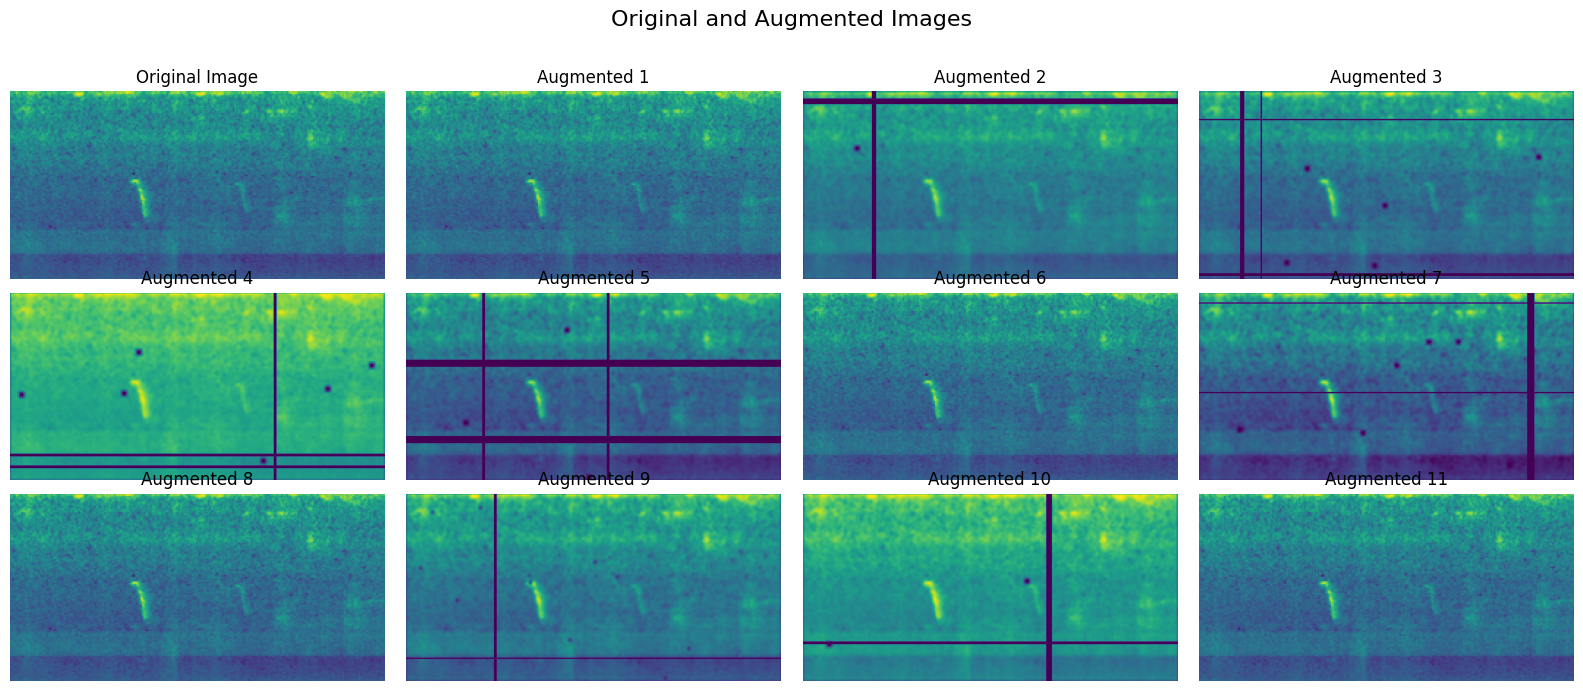

In [10]:
def show_image(img_tensor, title="Image", ax=None):
    """
    Display an image tensor using matplotlib.
    
    Args:
        img_tensor (torch.Tensor): Image tensor to display.
        title (str): Title of the image.
        ax (matplotlib.axes.Axes): Matplotlib axis to plot on.
    """
    if img_tensor.dim() == 3:
        img = img_tensor.squeeze(0).cpu().numpy()
    elif img_tensor.dim() == 2:
        img = img_tensor.cpu().numpy()
    else:
        raise ValueError("Unsupported image shape for visualization")
    
    if ax is None:
        plt.imshow(img, cmap="viridis")
        plt.title(title)
        plt.axis("off")
    else:
        ax.imshow(img, cmap="viridis")
        ax.set_title(title)
        ax.axis("off")

# Load the test image
test = read_image("/kaggle/input/image-train/image_train/wlwwar/XC757038_20.jpeg")

# Display statistics
stat = show_img_stats(test)

# Prepare the plot
fig, axs = plt.subplots(3, 4, figsize=(16, 7))
fig.suptitle("Original and Augmented Images", fontsize=16)

# Plot the original image in the first subplot
show_image(test, title="Original Image", ax=axs[0, 0])

# Plot augmented images in the remaining subplots
for i, ax in enumerate(axs.flat[1:], start=1):
    augmented_img = augment_image(test.clone())
    show_image(augmented_img, title=f"Augmented {i}", ax=ax)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to fit the title
plt.show()

In [11]:
# load model
base_model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

# remove the classification head
feature_extractor = nn.Sequential(
    *(list(base_model.children())[:-2])
)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 84.6MB/s]


In [12]:
class EfficientNetGRU(nn.Module):
    def __init__(self, hidden_size, num_classes, pretrained = True):
        super(EfficientNetGRU, self).__init__()
        self.feature_extractor = nn.Sequential(
            *(list(base_model.children())[:-2])
        )
        self.gru = nn.GRU(
            input_size=1280, # feature dimension from efficientnet b7
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
        )
        self.dropout = nn.Dropout(0.5) 
        self.fc = nn.Linear(hidden_size, num_classes)

    
    def forward(self, x):
        # Convert grayscale to RGB
        if len(x.size()) == 4:  # Check if the input is missing the sequence dimension
            x = x.unsqueeze(1)  # Add sequence dimension: (B, C, H, W) -> (B, 1, C, H, W)

        if x.size(2) == 1:  # Check if the input has 1 channel (grayscale)
            x = x.repeat(1, 1, 3, 1, 1)  # Convert (B, T, 1, H, W) -> (B, T, 3, H, W)

            
        # extract features
        batch_size, seq_length, channels, height, width = x.size()
        features = []
        for t in range(seq_length):
            # pass each frame through efficientnet
            out = self.feature_extractor(x[:, t, :, :, :]) # output shape (B, 2560, H, W)
            out = torch.mean(out, dim=(2,3)) # global average pooling, shape (B, 2560)
            features.append(out)
        features = torch.stack(features, dim=1) # shape (B, T, 2560)

        # pass features through gru
        gru_out, _ = self.gru(features) # shape (B, T, hidden_size)

        # dropout
        gru_out = self.dropout(gru_out[:, -1, :])  # Take the last GRU output, apply dropout

        # classification
        out = self.fc(gru_out) # take the last gru output
        return out
    

In [13]:
# Instantiate the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EfficientNetGRU(hidden_size=256, num_classes=264).to(device)

# Define the input shape: (batch_size, seq_length, channels, height, width)
input_shape = (2, 1, 3, 128, 256)  # Example batch_size=2, seq_length=1, channels=3, height=128, width=256

# Generate the summary
summary(model, input_size=input_shape, col_names=["input_size", "output_size", "num_params", "trainable"], depth=4)


Layer (type:depth-idx)                                       Input Shape               Output Shape              Param #                   Trainable
EfficientNetGRU                                              [2, 1, 3, 128, 256]       [2, 264]                  --                        True
├─Sequential: 1-1                                            [2, 3, 128, 256]          [2, 1280, 4, 8]           --                        True
│    └─Sequential: 2-1                                       [2, 3, 128, 256]          [2, 1280, 4, 8]           --                        True
│    │    └─Conv2dNormActivation: 3-1                        [2, 3, 128, 256]          [2, 32, 64, 128]          --                        True
│    │    │    └─Conv2d: 4-1                                 [2, 3, 128, 256]          [2, 32, 64, 128]          864                       True
│    │    │    └─BatchNorm2d: 4-2                            [2, 32, 64, 128]          [2, 32, 64, 128]          64                

In [14]:
class ModelCheckpoint:
    def __init__(self, filepath, monitor ="val_loss", mode="min", save_best_only=True, verbose = 1):
        self.filepath = filepath
        self.monitor = monitor
        self.mode = mode
        self.save_best_only = save_best_only
        self.verbose = verbose
        self.best_score = None
        self.comparison_fn = min if mode == 'min' else max

    def __call__(self, model, epoch, metrics):
        score =  metrics[self.monitor]
        if self.best_score is None or self.comparison_fn(score, self.best_score) == score:
            print(f"epoch {epoch}: {self.monitor} improved to {score:.4f}. Saving model...")
        torch.save(model.state_dict(), self.filepath)
        self.best_score = score


class EarlyStopping:
    def __init__(self, monitor="val_loss", mode = "min", patience = 5, verbose = 1):
        self.monitor = monitor
        self.mode = mode
        self.patience = patience
        self.verbose = verbose
        self.best_score = None
        self.wait = 0
        self.comparison_fn = min if mode == "min" else max
        self.stop = False

    def __call__(self, epoch, metrics):
        score = metrics[self.monitor]
        if self.best_score is None or self.comparison_fn(score, self.best_score) == score:
            self.best_score = score
            self.wait = 0
        else:
            self.wait += 1
            if self.verbose:
                print(f"EarlyStopping counter: {self.wait} out of {self.patience}")
            if self.wait >= self.patience:
                if self.verbose:
                    print(f"Early stopping triggered")
                self.stop = True

In [15]:
def show_history(history):
    """Show training and validation history"""
    history_frame = pd.DataFrame(history)
    history_frame.index = pd.RangeIndex(1, len(history_frame) + 1, name="epoch")
    display(history_frame.style\
        .highlight_min(color='lightgreen', subset=['val_loss'])\
        .highlight_max(color='lightgreen', subset=['val_acc'])
    )
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    history_frame[['loss', 'val_loss']].plot(ax=ax[0], title='Loss')
    history_frame[['acc', 'val_acc']].plot(ax=ax[1], title='Accuracy')
    plt.tight_layout()
    plt.show()


def compute_oof(model, valid_loader, device):
    """Compute Out-of-Fold (OOF) predictions"""
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for images, labels in valid_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            preds = torch.sigmoid(outputs)  # Assuming binary classification or sigmoid-based multi-label classification
            all_preds.append(preds.cpu().numpy())
            all_targets.append(labels.cpu().numpy())
    oof_pred = np.concatenate(all_preds, axis=0)
    oof_true = np.concatenate(all_targets, axis=0)
    oof_df = pd.DataFrame({"y_true": oof_true.tolist(), "y_pred": oof_pred.tolist()})
    return oof_df


In [16]:
def run_training(train_df, valid_df, model_name):
    """Run training in PyTorch"""
    # Prepare datasets
    train_loader = create_training_dataset(train_df)
    valid_loader = create_validation_dataset(valid_df)
    
    
    # Model, optimizer, and loss function
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = EfficientNetGRU(hidden_size=256, num_classes=cfg.n_label).to(device)
    optimizer = optim.Adam(model.parameters(), lr=cfg.lr)
    criterion = nn.CrossEntropyLoss()

    # Callbacks
    model_checkpoint = ModelCheckpoint(filepath=f"weights_{model_name}.pth", monitor="val_loss", mode="min", verbose=1)
    early_stopping = EarlyStopping(monitor="val_loss", mode="min", patience=cfg.patience, verbose=1)

    # Training loop
    history = {"loss": [], "val_loss": [], "acc": [], "val_acc": []}
    for epoch in range(cfg.epochs):
        print(f"Epoch {epoch+1}/{cfg.epochs}")
        
        # Training phase
        model.train()
        train_loss = 0
        correct = 0
        total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss /= total
        train_acc = 100. * correct / total

        # Validation phase
        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for batch_idx, (images, labels) in enumerate(valid_loader):
                try: 
                    images, labels = images.to(device), labels.to(device)
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                    val_loss += loss.item() * images.size(0)
                    _, predicted = outputs.max(1)
                    total += labels.size(0)
                    correct += predicted.eq(labels).sum().item()
                except Exception as e:
                    print(f"error at batch {batch_idx}: {e}")
                    break

        val_loss /= total
        val_acc = 100. * correct / total

        # Logging
        history["loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

        # Callbacks
        metrics = {"val_loss": val_loss, "val_acc": val_acc}
        model_checkpoint(model, epoch, metrics)
        early_stopping(epoch, metrics)
        if early_stopping.stop:
            print("Early stopping triggered.")
            break

    # Restore best weights
    model.load_state_dict(torch.load(f"weights_{model_name}.pth"))
    print(f"Best model restored from 'weights_{model_name}.pth'.")

    # Compute OOF predictions
    oof = compute_oof(model, valid_loader, device)

    return history, oof, model



# split into train, valid, test

In [17]:
np.random.seed(0)

def isolate_small_classes(data, label_col, threshold=10):
    """
    Isolate classes with ≤ `threshold` samples into a separate dataset.

    Args:
        data (DataFrame): Input dataset containing features and labels.
        label_col (str): Column name of the label in the dataset.
        threshold (int): Maximum number of samples to consider a class as small.

    Returns:
        small_class_data (DataFrame): Data containing small classes.
        rest_data (DataFrame): Data excluding small classes.
    """
    # Identify small classes
    small_classes = data[label_col].value_counts()[data[label_col].value_counts() <= threshold].index

    # Separate small class data
    small_class_data = data[data[label_col].isin(small_classes)]
    rest_data = data[~data[label_col].isin(small_classes)]

    return small_class_data, rest_data


def ensure_valid_class_distribution(valid_data, train_data, label_col, min_samples=3):
    """
    Ensure no class in `valid_data` has fewer than `min_samples` samples.
    If found, move those samples to `train_data`.

    Args:
        valid_data (DataFrame): Validation dataset.
        train_data (DataFrame): Training dataset.
        label_col (str): Column name of the label in the dataset.
        min_samples (int): Minimum number of samples a class must have in `valid_data`.

    Returns:
        train_data (DataFrame): Updated training dataset.
        valid_data (DataFrame): Updated validation dataset.
    """
    # Identify classes with fewer than `min_samples` in valid_data
    small_classes_in_valid = valid_data[label_col].value_counts()[valid_data[label_col].value_counts() < min_samples].index

    # Move these samples back to the training set
    for cls in small_classes_in_valid:
        train_data = pd.concat([train_data, valid_data[valid_data[label_col] == cls]])
        valid_data = valid_data[valid_data[label_col] != cls]

    return train_data, valid_data


# Step 1: Isolate classes with ≤ 5 samples
small_class_data, rest_data = isolate_small_classes(data, label_col=cfg.label, threshold=5)

# Step 2: Split the rest of the data into train and valid
train_data, valid_data = train_test_split(rest_data, test_size=cfg.test_size, stratify=rest_data[cfg.label], random_state=4)

# Step 3: Add small-class data back to the training set
train_data = pd.concat([train_data, small_class_data], ignore_index=True)

# Step 4: Ensure valid_data has no classes with fewer than 3 samples
train_set, valid_set = ensure_valid_class_distribution(valid_data, train_data, label_col=cfg.label, min_samples=3)

# Step 5: Optionally, split the valid set into valid and test sets
valid_set, test_set = train_test_split(
    valid_set, 
    test_size=cfg.test_size, 
    stratify=valid_set[cfg.label], 
    random_state=42
)



# Model name
model_name = f"{cfg.model_name}"
print(f"Model name: {model_name}")


Model name: EFF-b0-GRU-PyTorch


# training

Epoch 1/90
Train Loss: 4.4364, Train Acc: 15.95%
Val Loss: 3.3663, Val Acc: 33.80%
epoch 0: val_loss improved to 3.3663. Saving model...
Epoch 2/90
Train Loss: 3.0500, Train Acc: 39.87%
Val Loss: 2.5219, Val Acc: 48.78%
epoch 1: val_loss improved to 2.5219. Saving model...
Epoch 3/90
Train Loss: 2.4526, Train Acc: 50.19%
Val Loss: 2.1119, Val Acc: 56.07%
epoch 2: val_loss improved to 2.1119. Saving model...
Epoch 4/90
Train Loss: 2.1087, Train Acc: 56.48%
Val Loss: 1.8664, Val Acc: 60.39%
epoch 3: val_loss improved to 1.8664. Saving model...
Epoch 5/90
Train Loss: 1.8660, Train Acc: 60.94%
Val Loss: 1.6839, Val Acc: 63.99%
epoch 4: val_loss improved to 1.6839. Saving model...
Epoch 6/90
Train Loss: 1.6786, Train Acc: 64.44%
Val Loss: 1.5575, Val Acc: 66.54%
epoch 5: val_loss improved to 1.5575. Saving model...
Epoch 7/90
Train Loss: 1.5301, Train Acc: 67.51%
Val Loss: 1.4398, Val Acc: 69.01%
epoch 6: val_loss improved to 1.4398. Saving model...
Epoch 8/90
Train Loss: 1.3844, Train Acc:

/tmp/ipykernel_23/503510195.py:86: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"weights_{model_name}.pth"))


,loss,val_loss,acc,val_acc
epoch,,,,
1,4.436437,3.366276,15.946691,33.804381
2,3.050007,2.521879,39.865579,48.778339
3,2.452552,2.111884,50.194164,56.066176
4,2.108717,1.866370,56.482077,60.393689
5,1.865977,1.683936,60.940947,63.993566
6,1.678610,1.557541,64.435892,66.540288
7,1.530052,1.439793,67.509191,69.014246
8,1.384401,1.343437,70.303309,70.871630
9,1.269905,1.275399,72.730928,72.399663


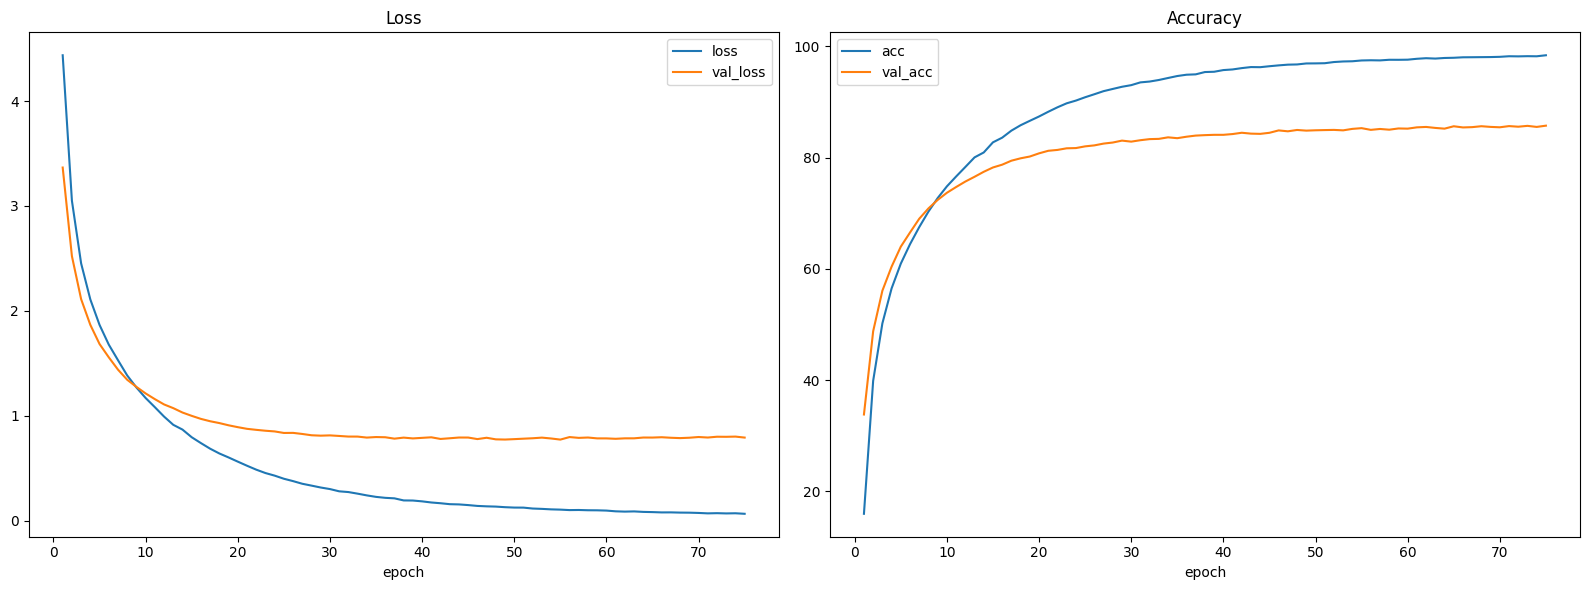

In [18]:
# Run training
history, oof, model = run_training(train_set, valid_set, model_name)

# Visualize training history
show_history(history)

# save csv file

In [19]:
oof.to_csv("oof.csv")

# calculate accuracy, f1, recall, precission metrics

In [20]:
# Ensure data is on the correct device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the model
model = EfficientNetGRU(hidden_size=256, num_classes=cfg.n_label).to(device)  # Replace with your actual model architecture
model.load_state_dict(torch.load("/kaggle/working/weights_EFF-b0-GRU-PyTorch.pth", map_location = device))
model.eval()  # Set model to evaluation mode

# Initialize lists to collect true labels and predictions
true_labels = []
pred_labels = []

# Create test DataLoader
print(f"test_set size: {len(test_set)}")
test_loader = create_validation_dataset(test_set)

# Evaluation loop
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Make predictions
        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)

        # Collect predictions and true labels
        true_labels.extend(labels.cpu().numpy())
        pred_labels.extend(predictions.cpu().numpy())

# Convert to numpy arrays
true_labels = np.array(true_labels)
pred_labels = np.array(pred_labels)

# Compute metrics
# Accuracy
accuracy = accuracy_score(true_labels, pred_labels)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Precision, Recall, F1-score
precision = precision_score(true_labels, pred_labels, average='macro', zero_division=0)
recall = recall_score(true_labels, pred_labels, average='macro', zero_division=0)
f1 = f1_score(true_labels, pred_labels, average='macro', zero_division=0)


print("Precision:", precision)
print("Recall:", recall)
print("f1", f1)


/tmp/ipykernel_23/322339679.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/kaggle/working/weights_EFF-b0-GRU-PyTorch.pth", map_locati

test_set size: 11201
Accuracy: 85.98%
Precision: 0.8213933201755106
Recall: 0.7867510901642888
f1 0.7968583597624864


# calculate cmAP on testset

In [21]:
def padded_cmap(solution, submission, padding_factor=5):
    solution = solution.drop(['row_id'], axis=1, errors='ignore')
    submission = submission.drop(['row_id'], axis=1, errors='ignore')
    new_rows = []
    for i in range(padding_factor):
        new_rows.append([1 for i in range(len(solution.columns))])
    new_rows = pd.DataFrame(new_rows)
    new_rows.columns = solution.columns
    padded_solution = pd.concat([solution, new_rows]).reset_index(drop=True).copy()
    padded_submission = pd.concat([submission, new_rows]).reset_index(drop=True).copy()
    score = sklearn.metrics.average_precision_score(
        padded_solution.values,
        padded_submission.values,
        average='macro',
    )
    return score

# convert true_labels to onehot
n_classes = max(true_labels) + 1  # Assuming classes are 0-indexed
true_labels_one_hot = np.zeros((len(true_labels), n_classes))
true_labels_one_hot[np.arange(len(true_labels)), true_labels] = 1
true_labels_df = pd.DataFrame(true_labels_one_hot, columns=[f'class_{i}' for i in range(n_classes)])

# convert pred_labels to probabitily
pred_probs = np.zeros((len(pred_labels), n_classes))
pred_probs[np.arange(len(pred_labels)), pred_labels] = 1
pred_probs_df = pd.DataFrame(pred_probs, columns=[f'class_{i}' for i in range(n_classes)])



cmAP_score = padded_cmap(true_labels_df, pred_probs_df, padding_factor=5)
print(f"Class mean Average Precision (cmAP): {cmAP_score}")

Class mean Average Precision (cmAP): 0.7591986281305526
